In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Regularized Policy Optimization

PPO constrains each policy update relative to the preceding policy. A different objective keeps the policy near a fixed reference by subtracting a KL-divergence penalty from expected reward. This changes the optimum, not only the path taken by the optimizer, and it includes entropy regularization as the special case of a uniform reference.

We first examine why such a reference can be useful when rewards are learned from preferences. A reward model is accurate only where its comparison data provide information, and optimizing it can exploit errors elsewhere. A tabular gridworld makes this failure measurable against the true reward. We then derive the KL-regularized optimum, its soft Bellman backup, and its connections to language-model post-training and maximum-entropy reinforcement learning.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import numpy as np

## Learning Rewards from Preferences

For many tasks, such as evaluating a helpful answer or a safe driving maneuver, an explicit numerical reward is difficult to specify. Pairwise comparisons are often easier to obtain. Preference-based reinforcement learning fits a reward model to these comparisons and then optimizes the learned reward [@Christiano.Leike.Brown.ea.2017]. We represent the comparison model with logistic regression.

### Preferences and the Bradley-Terry Model

The Bradley-Terry model [@Bradley.Terry.1952] assigns each candidate a scalar score, here the return of a trajectory, and models a comparison as a noisy observation of the score difference:

$$P(\tau \succ \tau') = \sigma\big( r(\tau) - r(\tau') \big), \qquad \sigma(u) = \frac{1}{1 + e^{-u}}.$$

Fitting $r$ by maximum likelihood on labeled pairs is logistic regression on feature differences. We use a $4 \times 4$ gridworld with deterministic moves, an absorbing goal in the far corner worth $+1$, a living cost of $-0.04$ per step, and two central hazard cells that cost $-1.5$ to enter. The reference policy $\pi_{\textrm{ref}}$ is a softmax over the true action values at temperature $0.25$. It reaches the goal but remains stochastic, and it rarely enters the hazard lane.

In [2]:
gamma = 0.95                                   # a 4 x 4 gridworld
P = np.zeros((16, 4, 16))
for s, a in np.ndindex(16, 4):
    x, y = s % 4, s // 4
    dx, dy = [(-1, 0), (0, 1), (1, 0), (0, -1)][a]   # left, down, right, up
    P[s, a, min(3, max(0, y + dy)) * 4 + min(3, max(0, x + dx))] = 1.0
P[15], P[15, :, 15] = 0.0, 1.0                 # the goal absorbs
bonus = np.full(16, -0.04)                     # every step costs a little
bonus[[5, 6]], bonus[15] = -1.5, 1.0           # a hazard lane; the goal pays
r_true = np.einsum('sat,t->sa', P, bonus)      # r*(s, a): the entered bonus
r_true[15] = 0.0
mdp = d2l.TabularMDP(P, r_true, gamma)
Q_true = mdp.backup(d2l.value_iteration(mdp, 200)[-1])
pi_ref = np.exp(Q_true / 0.25)                 # competent but hedging
pi_ref /= pi_ref.sum(1, keepdims=True)

We next withhold $r^*$ and estimate it from comparisons. We collect one
thousand trajectories from $\pi_{\textrm{ref}}$ and represent each by its
discounted visit counts $x(\tau)$, for which the true return is
$x(\tau)^\top r^*$. We sample six thousand pairs, label them according to
the equation, and fit $\hat r$ by logistic regression on
feature differences. A stated weight-decay coefficient regularizes this
finite diagnostic:

In [3]:
rng = np.random.default_rng(0)

def sample_traj(pi, T=40):
    s, x = 0, np.zeros((16, 4))
    for t in range(T):
        a = rng.choice(4, p=pi[s])
        x[s, a] += gamma ** t                  # discounted visits: R = x . r
        s = P[s, a].argmax()
        if s == 15:
            break
    return x.ravel()

X = np.stack([sample_traj(pi_ref) for _ in range(1000)])
R = X @ r_true.ravel()                         # true returns; the fit never sees them
i, j = rng.integers(0, 1000, (2, 6000))
y = (rng.random(6000) < 1 / (1 + np.exp(R[j] - R[i]))).astype(float)
D = X[i] - X[j]
w = np.zeros(64)
for _ in range(4000):                          # logistic regression on (D, y)
    w += 0.5 * (D.T @ (y - 1 / (1 + np.exp(-D @ w))) / len(y) - 0.02 * w)
r_hat = w.reshape(16, 4)
core = (X > 0).sum(0).reshape(16, 4) >= 50     # pairs seen in >= 50 episodes
print(f'never visited: {(X.sum(0) == 0).sum()} pairs; '
      f'in at least 50 episodes: {core.sum()} pairs')
print(f'rms fit error on those {core.sum()}: '
      f'{np.sqrt(((r_hat - r_true)[core] ** 2).mean()):.3f}')
print(f'entries into the hazard lane: true '
      f'{np.round(r_true[[1, 4, 2, 5], [1, 2, 1, 2]], 2)}, '
      f'fitted {np.round(r_hat[[1, 4, 2, 5], [1, 2, 1, 2]], 2)}')

never visited: 9 pairs; in at least 50 episodes: 46 pairs
rms fit error on those 46: 0.193
entries into the hazard lane: true [-1.5 -1.5 -1.5 -1.5], fitted [-0.03 -0.05 -0.02  0.  ]


The fit has an rms error of $0.19$ on the forty-six state-action pairs visited by the reference policy. Nine pairs are absent from the data, so their fitted rewards remain at the initialization value of zero. This matters for the hazard lane: entering it has true reward $-1.5$, but the fitted model assigns a value near zero because the reference policy rarely provides comparisons there. In this example, zero initialization and weight decay make unsupported predictions remain near zero. A neural reward model need not behave this way and may extrapolate unpredictably outside the data distribution.

### Identifiability and the Per-Prompt Baseline

A comparison includes two trajectories from the *same* start state, so the equation depends only on score differences. In the prompt-response notation used at scale, shifting the reward by any function of the prompt, $r(x, y) \to r(x, y) + f(x)$, leaves every difference and therefore the likelihood unchanged; exercise 5 asks you to verify this result. A learned reward is thus identified only *relative to each prompt*, and its absolute level per prompt is a convention. Subtracting a per-prompt baseline does not change the comparison model. Independently, the zero-mean lemma of that section shows that subtracting any function of the state from the policy-gradient weight preserves unbiasedness. The group mean used by GRPO (that section) combines these two properties, subject to the self-inclusion qualification developed later.

### Dense versus Terminal Rewards

Our comparisons score complete trajectories, so $\hat r$ is trained on
end-to-end evidence. At scale, an outcome reward model (ORM) likewise
scores a completed response, whereas a process reward model (PRM) scores
intermediate steps. Intermediate rewards provide denser credit-assignment
signals but require additional labels and introduce more opportunities for
misspecification. Potential-based shaping is the standard densification
that preserves the optimal policy under its stated conditions
[@Ng.Harada.Russell.1999].

## Optimizing a Proxy Reward

We now optimize $\hat{r}$ directly with value iteration.

### Reward Hacking and Goodhart's Law

Goodhart's law describes the loss of validity that can occur when a measure becomes an optimization target. In reinforcement learning, *reward hacking* denotes policies that score highly under a specified or fitted reward while violating the intended objective; many examples are catalogued in [@Krakovna.Uesato.Mikulik.ea.2020]. The shaped-bonus example in that section had the same mechanism: optimization uses errors in the estimated objective. There the error was specified manually; here it is statistical. We plan optimally under $\hat{r}$ with value iteration (that section) and evaluate the resulting policy under $r^*$:

In [4]:
def plan(r):
    m = d2l.TabularMDP(P, r, gamma)
    return np.eye(4)[m.backup(d2l.value_iteration(m, 200)[-1]).argmax(1)]

def ret(pi, r):
    m = d2l.TabularMDP(P, r, gamma)
    return d2l.policy_evaluation(m, pi, 400)[-1][0]

for name, r in (('true reward  ', r_true), ('fitted reward', r_hat)):
    pi = plan(r)
    print(f'plan on {name}: fitted return {ret(pi, r_hat):+.2f}, '
          f'true return {ret(pi, r_true):+.2f}')

plan on true reward  : fitted return -0.24, true return +0.59
plan on fitted reward: fitted return -0.03, true return -2.11


Under the fitted reward, the optimized policy scores $-0.03$, compared with $-0.24$ for the reference policy; only the difference is meaningful because the additive reward constant is unidentified. Under the true reward, however, the scores are $-2.11$ and $+0.59$. The optimized policy enters the hazard lane because its unsupported rewards were estimated near zero. Value iteration has optimized the supplied reward correctly; the failure lies in the reward model outside the reference policy's data distribution. that section encounters the same problem for learned value functions.

### True Return against the KL Budget

The available evidence supports $\hat{r}$ primarily on trajectories sampled from $\pi_{\textrm{ref}}$. We therefore measure policy displacement from the reference with the KL divergence. For each coefficient $\beta$, we compute the policy that maximizes $\sum_t \gamma^t \big( \hat{r}_t - \beta\, D_{\textrm{KL}}( \pi(\cdot \mid s_t) \Vert \pi_{\textrm{ref}}(\cdot \mid s_t) ) \big)$, thereby tracing fitted and true return as functions of divergence. The next section derives this objective for a single decision and proves its optimum in closed form; in an MDP the optimum must also account for every *later* step's reward and penalty, and it does so through a $\beta$-dependent soft action value: replace value iteration's hard-max backup (that section) with the reference-weighted soft one,

$$V_\beta(s) = \beta \log \sum_a \pi_{\textrm{ref}}(a \mid s)\, e^{Q_\beta(s, a)/\beta}, \qquad Q_\beta(s, a) = \hat{r}(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V_\beta(s'),$$

whose fixed point gives the exactly optimal policy $\pi_\beta(a \mid s) \propto \pi_{\textrm{ref}}(a \mid s)\, e^{Q_\beta(s, a)/\beta}$. The next section derives this backup. Like the ordinary Bellman backup of that section, it is a contraction, and the loop below solves its fixed point for each $\beta$. The printed residual measures numerical convergence. Large $\beta$ keeps the policy close to the reference, whereas small $\beta$ approaches the fitted-reward maximizer. For each $\pi_\beta$, we record true return, fitted return, and the discounted sum of per-state divergences from the reference along trajectories generated by $\pi_\beta$:

largest soft Bellman residual across the sweep: 0.0e+00
true return -0.10 at KL 0, peak +0.53 at KL 3.7, then -1.83 at KL 14.2


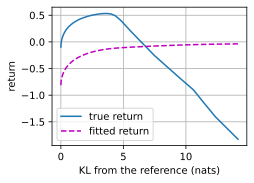

In [5]:
def soft_v(r, beta, num_iters=400):
    """Soft value iteration for the KL-penalized objective: iterate
    V(s) <- beta log sum_a pi_ref(a|s) exp((r + gamma P V)(s, a) / beta)."""
    V = np.zeros(16)
    for _ in range(num_iters):
        Q = r + gamma * np.einsum('sat,t->sa', P, V)
        m = Q.max(1)
        V = m + beta * np.log(
            (pi_ref * np.exp((Q - m[:, None]) / beta)).sum(1))
    return V

kls, true_ret, prox_ret, resid = [], [], [], 0.0
for beta in np.logspace(1, -2.5, 36):
    V_b = soft_v(r_hat, beta)
    Q_b = r_hat + gamma * np.einsum('sat,t->sa', P, V_b)
    m = Q_b.max(1, keepdims=True)
    pi = pi_ref * np.exp((Q_b - m) / beta)     # the exact optimum: pi_ref
    pi /= pi.sum(1, keepdims=True)             # tilted by the soft Q_beta
    back = m[:, 0] + beta * np.log(
        (pi_ref * np.exp((Q_b - m) / beta)).sum(1))
    resid = max(resid, np.abs(back - V_b).max())   # Bellman residual
    kl = (pi * np.log(np.where(pi > 0, pi / pi_ref, 1.0))).sum(1)
    kl[15] = 0.0                               # no decisions once absorbed
    rho = np.linalg.solve(np.eye(16) - gamma
                          * np.einsum('sa,sat->st', pi, P).T, np.eye(16)[0])
    kls.append(rho @ kl)
    true_ret.append(ret(pi, r_true))
    prox_ret.append(ret(pi, r_hat))
k = int(np.argmax(true_ret))
print(f'largest soft Bellman residual across the sweep: {resid:.1e}')
print(f'true return {true_ret[0]:+.2f} at KL 0, peak {true_ret[k]:+.2f} '
      f'at KL {kls[k]:.1f}, then {true_ret[-1]:+.2f} at KL {kls[-1]:.1f}')
d2l.plot(kls, [true_ret, prox_ret], 'KL from the reference (nats)', 'return',
         legend=['true return', 'fitted return'])

Every point in this figure is an optimum of the penalized objective; the Bellman residual is zero to double precision. The fitted return increases throughout the sweep. The true return instead rises from $-0.10$ to $+0.53$ at a divergence just below four nats, and then decreases sharply as the policy concentrates on the hazard lane. Moderate optimization of the imperfect reward model improves the true return, whereas further optimization exploits its unsupported predictions. A similar nonmonotonic relation has been observed when language models are optimized against a learned reward and evaluated by a separate reference measure [@Gao.Schulman.Hilton.2023]. This motivates controlling the divergence from the reference policy directly.

## The Regularized Objective

Whereas that section maximized expected reward, a fixed-reference penalty can restrict optimization of a learned reward to policies near the data-generating policy. For a single decision with reward $r(a)$ over a finite action set, reference $\pi_{\textrm{ref}}$, and coefficient $\beta > 0$, the regularized objective is

$$\max_{\pi}\ E_{a \sim \pi}\big[ r(a) \big] - \beta\, D_{\textrm{KL}}\big( \pi \Vert \pi_{\textrm{ref}} \big).$$

The penalty is part of the objective rather than a constraint on a single update. The coefficient $\beta$ sets its weight relative to reward, and the reference policy remains fixed.

### The Closed-Form Optimum

**Proposition.** For $\beta > 0$, the objective the equation is maximized by the unique policy

$$\pi^\star(a) = \frac{1}{Z}\, \pi_{\textrm{ref}}(a)\, e^{r(a)/\beta}, \qquad Z = \sum_{a} \pi_{\textrm{ref}}(a)\, e^{r(a)/\beta},$$

and the maximal value is $\beta \log Z$.

**Proof.** By construction $r(a) = \beta \log\big( \pi^\star(a) Z / \pi_{\textrm{ref}}(a) \big)$. Substituting into the objective, for any policy $\pi$,

$$E_\pi[r] - \beta D_{\textrm{KL}}(\pi \Vert \pi_{\textrm{ref}}) = \sum_a \pi(a)\, \beta \log \frac{\pi^\star(a)\, Z}{\pi(a)} = \beta \log Z - \beta\, D_{\textrm{KL}}(\pi \Vert \pi^\star).$$

Gibbs' inequality, proved in that section, says the remaining divergence is nonnegative and zero exactly when $\pi = \pi^\star$. $\blacksquare$

The optimum multiplies the reference by an exponential tilt and then renormalizes it, and the achieved value is a log-partition function. the figure illustrates this relation. Two boundary cases complete the statement. The optimum inherits the reference's support: if $\pi_{\textrm{ref}}(a) = 0$, any policy placing mass on $a$ has infinite divergence, so the equation correctly assigns $a$ zero probability, and no finite reward can assign positive probability to an action excluded by the reference. And as $\beta \to 0$ the limit is a point mass only when the best action is unique; with ties, it is the reference renormalized over the maximizing set. We verify the proposition numerically by solving the equation with exponentiated gradient ascent, using multiplicative updates renormalized onto the simplex; the $+1$ in the exact gradient $r - \beta(\log(\pi/\pi_{\textrm{ref}}) + 1)$ is constant across actions and cancels during normalization, so we drop it:

In [6]:
p_ref = np.array([0.30, 0.10, 0.25, 0.20, 0.15])
r = np.array([0.0, 0.5, 1.0, 2.0, 3.0])

def solve_kl(r, p, beta, steps=3000, eta=0.3):
    pi = np.full_like(p, 1 / len(p))
    for _ in range(steps):                     # exponentiated gradient ascent
        pi = pi * np.exp(eta * (r - beta * np.log(pi / p)))
        pi /= pi.sum()
    return pi

for beta in (5.0, 2.0, 0.5, 0.2):
    pi = solve_kl(r, p_ref, beta)
    print(f'beta = {beta:3}: pi_beta = {np.round(pi, 3)}, '
          f'reward {pi @ r:.2f}, KL {(pi * np.log(pi / p_ref)).sum():.2f}')

beta = 5.0: pi_beta = [0.233 0.086 0.237 0.232 0.212], reward 1.38, KL 0.02
beta = 2.0: pi_beta = [0.146 0.062 0.2   0.264 0.327], reward 1.74, KL 0.15
beta = 0.5: pi_beta = [0.004 0.004 0.025 0.148 0.819], reward 2.78, KL 1.26
beta = 0.2: pi_beta = [0.    0.    0.    0.009 0.991], reward 2.99, KL 1.84


Then compare against the equation, closed form against converged iterate, and the value against $\beta \log Z$:

In [7]:
def pi_star(r, p, beta):
    star = p * np.exp((r - r.max()) / beta)    # eq_kl_optimum, stabilized
    return star / star.sum()

gap = max(np.abs(solve_kl(r, p_ref, b) - pi_star(r, p_ref, b)).max()
          for b in (5.0, 2.0, 0.5, 0.2))
pi2 = solve_kl(r, p_ref, 2.0)
print(f'largest gap to the closed form over the ladder: {gap:.1e}')
print(f'objective at beta = 2: numerical '
      f'{pi2 @ r - 2.0 * (pi2 * np.log(pi2 / p_ref)).sum():.6f}, '
      f'beta log Z = {2.0 * np.log(p_ref @ np.exp(r / 2.0)):.6f}')

largest gap to the closed form over the ladder: 1.4e-16
objective at beta = 2: numerical 1.442004, beta log Z = 1.442004


Across the tested values of $\beta$, the largest disagreement is at floating-point resolution, and the achieved objective matches $\beta \log Z$ to six decimal places. This confirms the exact finite-action result numerically.

![The optimum of the penalized objective shown as a product. Each row multiplies the reference $\pi_{\textrm{ref}} = (0.30,\ 0.10,\ 0.25,\ 0.20,\ 0.15)$ by the tilt $e^{r/\beta}$ for the reward $r = (0,\ 0.5,\ 1,\ 2,\ 3)$ and renormalizes, giving $\pi^\star$; the top row uses $\beta = 2$, the bottom $\beta = 0.2$. The reference is deliberately not monotone in the reward, and its dip at $a_2$ survives into $\pi^\star$ in both rows: $\pi^\star$ is a reweighting of the reference, not a ranking of the reward. The stronger tilt has greater divergence, $D_{\textrm{KL}}(\pi^\star \Vert \pi_{\textrm{ref}}) = 0.15$ in the top row and $1.84$ in the bottom, and the margins annotate the two limits: $\beta \to \infty$ returns the reference, $\beta \to 0$ a point mass on the best action.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-kl-tilting.svg)

### Four Consequences of the Closed Form

**Without the penalty, the optimum is a point mass.** Send $\beta \to 0$ in the equation and all mass flows to the highest-reward action, or, under ties, to the reference's distribution over the tied set; that is just the unregularized problem, whose solution was always the argmax. This result characterizes the *optimum*, not the dynamics of a particular training run. The entropy decrease measured in that section is consistent with movement toward the deterministic optimum of the unregularized objective. Regularization can instead make a stochastic policy optimal.

**The coefficient controls the interpolation.** The closed form gives the following limiting cases:

In [8]:
for beta in (100.0, 0.01):
    print(f'beta = {beta:6}: pi_star = {np.round(pi_star(r, p_ref, beta), 3)}')

beta =  100.0: pi_star = [0.297 0.099 0.25  0.202 0.153]
beta =   0.01: pi_star = [0. 0. 0. 0. 1.]


$\beta \to \infty$ reproduces the reference; $\beta \to 0$ is greedy; every policy between is an exact optimum of some exchange rate between reward and divergence.

**A uniform reference is the entropy bonus.** Against a uniform reference, $D_{\textrm{KL}}(\pi \Vert \textrm{uniform}) = \log |\mathcal{A}| - H(\pi)$, so the penalty *is* an entropy bonus up to a constant, and the equation becomes the maximum-entropy objective. The closed form specializes to a softmax of the reward:

In [9]:
boltzmann = np.exp(r / 0.5) / np.exp(r / 0.5).sum()
print(np.allclose(pi_star(r, np.full(5, 0.2), 0.5), boltzmann))

True


This is the form of that section's softmax policies. The Boltzmann exploration distribution in that section is also the optimizer of an entropy-regularized one-step objective, with temperature corresponding to $\beta$. The sequential version of this consequence is the soft backup, which closes the section.

**A posterior interpretation.** Equation the equation has the
form of Bayes' rule: $\pi_{\textrm{ref}}$ is a prior, $e^{r/\beta}$ an
unnormalized likelihood, $\pi^\star$ a posterior, and $Z$ the normalizer.
Control-as-inference methods use this identity to interpret rewards as
log-likelihoods of optimality events and regularized policy optimization
as variational inference [@Levine.2018; @Korbak.Perez.Buckley.2022].
The analogy permits selected inference tools, but it does not by itself
establish their approximation quality or empirical advantage for policies.

Sweeping $\beta$ traces the exact reward--divergence frontier for the finite-action example. The gridworld experiment evaluates an analogous frontier using the imperfect estimate $\hat{r}$:

KL 0 pays 1.15; the frontier ends at KL 1.90, reward 3


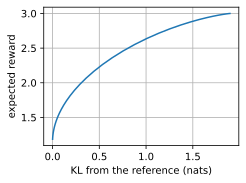

In [10]:
front = np.stack([pi_star(r, p_ref, b) for b in np.logspace(1.5, -1.5, 61)])
kl_f = (front * np.log(front / p_ref)).sum(1)
print(f'KL 0 pays {p_ref @ r:.2f}; the frontier ends at KL '
      f'{np.log(1 / p_ref[r.argmax()]):.2f}, reward {r.max():.0f}')
d2l.plot(kl_f, front @ r, 'KL from the reference (nats)', 'expected reward')

With true reward on the vertical axis, the frontier is concave and increasing (exercise 2), so its marginal reward gain per nat decreases. The gridworld curve is nonmonotonic because optimization uses the fitted reward while evaluation uses true return. The two rows of the figure are two points on this curve.

### Trust Region versus Penalty

Trust-region and fixed-reference methods both use KL divergence but in different roles.

> **Two uses of KL divergence.** A **trust region** (that section) measures divergence from the *previous iterate*. It restricts each update and protects a local approximation, while its reference changes after the update. A **fixed-reference penalty** (this section) is part of the objective and changes the optimum to the equation. PPO-style language-model fine-tuning can use both: a clipped surrogate relative to the sampling policy for update stability, and a reward penalty relative to the frozen initial model to control the final policy [@ouyang2022training].

### The Direction of the KL Divergence

$D_{\textrm{KL}}(\pi \Vert \pi_{\textrm{ref}})$ is the *reverse* divergence in the taxonomy of that section. Because it is an expectation under $\pi$, it can be estimated from policy samples. It penalizes assigning probability where the reference has little support but does not penalize assigning zero probability to reference modes, producing mode-seeking behavior. The forward direction $D_{\textrm{KL}}(\pi_{\textrm{ref}} \Vert \pi)$ instead penalizes failure to cover behavior sampled by the reference. The direction is therefore a modeling choice with different coverage effects.

## The Soft Backup and Its Consequences

### Maximum-Entropy Reinforcement Learning and the Soft Backup

The preceding derivation concerned one decision. In an MDP the penalty is applied at every step, $\sum_t \gamma^t \big( r_t - \beta\, D_{\textrm{KL}}( \pi(\cdot \mid s_t) \Vert \pi_{\textrm{ref}}(\cdot \mid s_t) ) \big)$, the objective our gridworld sweep optimized, and the proposition applies state by state with an action value in place of $r$, under one precaution the gridworld code already took: the value entering the tilt must itself account for every later step's reward *and* penalty, which makes it the $\beta$-dependent soft value $Q_\beta$ rather than the unregularized $Q^*$; tilting the reference by $Q^*$ is a different, merely heuristic family that is the exact optimum of no exchange rate. Writing the proposition's achieved value $\beta \log Z$ into the Bellman equation of that section replaces the hard maximum with a soft one,

$$V(s) = \max_a Q(s, a) \quad \textrm{becomes} \quad V(s) = \beta \log \sum_a \pi_{\textrm{ref}}(a \mid s)\, e^{Q(s, a)/\beta},$$

the backup that `soft_v` iterated to a fixed point, with residual zero to double precision. It replaces the maximum by a log-sum-exp, recovering the ordinary $\max$ as $\beta \to 0$. With a uniform reference, this is *soft value iteration* and the objective is maximum-entropy reinforcement learning. The smooth backup provides an alternative to the hard maximum whose estimation bias was discussed in that section. Exercise 6 applies this backup to the slippery lake and varies $\beta$ from value iteration toward policy evaluation.

### DDPG, TD3 and SAC

The same components appear in three continuous-control methods. DDPG [@Lillicrap.Hunt.Pritzel.ea.2016] trains a deterministic actor by the pathwise gradient of that section through a learned critic, off-policy from a replay buffer, with target networks; it reuses samples efficiently but can be unstable. TD3 [@Fujimoto.vanHoof.Meger.2018] diagnoses the brittleness largely as the maximization bias that section demonstrated on a table: an actor optimized against a critic can exploit positive critic errors, so TD3 trains *twin* critics and takes their minimum, the bias argument applied twice, plus delayed actor updates and target smoothing. SAC [@Haarnoja.Zhou.Abbeel.ea.2018] replaces the deterministic actor with a stochastic one and maximizes exactly this section's objective with a uniform reference: its "soft" critics implement the soft backup above, its entropy term is our penalty, its actor update is the pathwise gradient again, its twin critics are TD3's repair. The remaining mechanism is the change-of-variables correction SAC needs because its Gaussian actions are squashed through a $\tanh$ to fit bounded action spaces: squashing changes densities, so a log-determinant term joins the log-probabilities. The correction contributes one Jacobian term per action dimension. that section derives it, combines these components into the full algorithm, and evaluates return and critic calibration.

### Connections to Later Sections

Three later sections use these results. that section studies the hard $\max$ under function approximation as the $\beta\to0$ limit. that section studies a related distribution-shift problem with a fixed dataset and subtracts a pessimistic penalty where data are scarce rather than penalizing divergence from a reference policy. that section applies the equation to language-model sequences, using a pretrained model as the reference and a reward learned from preferences. It also rearranges the equation to express reward differences through policy log-ratios.

## Summary

Pairwise preferences identify reward differences but not an additive term depending only on the start state. A learned reward is reliable only on regions supported by its comparison data, and optimizing it can exploit errors elsewhere. A KL penalty relative to a fixed reference changes the objective and limits this displacement. Its exact optimum is the reference distribution exponentially tilted by reward, with value $\beta\log Z$. A uniform reference yields entropy regularization, and the corresponding Bellman update replaces a maximum by a log-sum-exp. Unlike a trust region relative to the previous iterate, a fixed-reference penalty changes the final optimum.

**Experimental scope.** The closed-form bandit calculations are exact. The gridworld experiment uses one map, one reference policy, and one seeded preference dataset. For that dataset, fitted return increases after true return begins to decrease, demonstrating overoptimization of the proxy. The location and size of this effect depend on the preference coverage and chosen hazard cost.

## Exercises

1. [conceptual] *Three limits.* Derive $\beta \to 0$, $\beta \to \infty$ and
   $\pi_{\textrm{ref}}$ uniform from the proposition, and say which one you have
   already met and where.
1. [short-code] *The frontier is concave.* Sweep $\beta$ and plot achieved
   reward against $D_{\textrm{KL}}(\pi_\beta \Vert \pi_{\textrm{ref}})$; verify
   concavity and explain what the slope at each point is.
1. [short-code] *Break the reward.* Perturb the fitted $\hat r$ at one
   rarely-visited state and rerun; how much KL budget does the optimizer need
   before it finds the error?
1. [conceptual] *Trust region or penalty.* For each of TRPO, PPO's clip, RLHF's
   KL term and on-policy distillation, say which of the two it is and what it
   is measured against.
1. [conceptual] *Identifiability.* Show $r(x,y) \to r(x,y) + f(x)$ leaves the
   Bradley-Terry likelihood unchanged, and deduce that a per-prompt baseline
   costs nothing.
1. [extended] *The soft backup, transplanted.* The measurement cell's
   `soft_v` solved the regularized Bellman equations on the hazard grid.
   Port it to the slippery lake with a uniform reference, plot
   $V_\beta^\star(s_0)$ against $\beta$, identify the two limits, and check
   the $\beta \to 0$ end against that section's value iteration.

[Discussions](https://d2l.discourse.group/)